# BirdCLEF+ 2026 — EDA (Kaggle)



In [17]:
import os, sys, shutil, importlib
from pathlib import Path
import numpy as np
import pandas as pd

# ---- Hardcoded Kaggle paths ----------------------------------------------
DATA = Path('/kaggle/input/competitions/birdclef-2026')
CODE_ROOT = Path('/kaggle/input/datasets/ahmedsherif382/birdclef2026-code')

# Inner package dirs (the uploaded dataset is doubly nested).
SRC_DIR = CODE_ROOT / 'src' / 'src'              # has taxonomy.py, audio.py, ...
DP_DIR  = CODE_ROOT / 'data_prep' / 'data_prep'  # has make_folds.py, ...
assert (SRC_DIR / 'taxonomy.py').exists(), f'missing {SRC_DIR}/taxonomy.py'
assert (DP_DIR / 'make_folds.py').exists(), f'missing {DP_DIR}/make_folds.py'
assert (DATA / 'taxonomy.csv').exists(), f'missing {DATA}/taxonomy.csv'

# Copy inner dirs to /kaggle/working so imports are clean and writable.
WORK = Path('/kaggle/working')
for src_dir, name in ((SRC_DIR, 'src'), (DP_DIR, 'data_prep')):
    dst = WORK / name
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src_dir, dst)

# Clear any cached imports of src/data_prep from a previous cell run, then
# put /kaggle/working first on sys.path.
for mod in list(sys.modules):
    if mod == 'src' or mod.startswith('src.') or mod == 'data_prep' or mod.startswith('data_prep.'):
        del sys.modules[mod]
sys.path[:] = [str(WORK)] + [p for p in sys.path if p not in (str(WORK),)]

os.environ['BIRDCLEF_DATA'] = str(DATA)
print('data root: ', DATA)
print('code root: ', WORK)

from src.taxonomy import class_list, num_classes  # noqa: E402

train = pd.read_csv(DATA / 'train.csv')
ss = pd.read_csv(DATA / 'train_soundscapes_labels.csv')
tax = pd.read_csv(DATA / 'taxonomy.csv')
print(f'train.csv: {len(train):,}  |  ss labels: {len(ss):,}  |  classes: {num_classes()}')


data root:  /kaggle/input/competitions/birdclef-2026
code root:  /kaggle/working
train.csv: 35,549  |  ss labels: 1,478  |  classes: 234


## 1. Class coverage across sources
Identify classes whose only training signal is the labeled soundscapes — these are the hardest cases and must not be filtered out anywhere in the pipeline.

In [18]:
focal_classes = set(train['primary_label'].unique())

ss_classes: set[str] = set()
for v in ss['primary_label'].dropna():
    for c in str(v).replace(',', ';').split(';'):
        c = c.strip()
        if c:
            ss_classes.add(c)

all_cols = set(class_list())
only_ss = (ss_classes - focal_classes) & all_cols
only_focal = (focal_classes - ss_classes) & all_cols
missing_from_train = all_cols - focal_classes - ss_classes

print(f'classes only in labeled soundscapes:      {len(only_ss)}')
print(f'classes only in focal (train_audio):       {len(only_focal)}')
print(f'classes absent from BOTH training sources: {len(missing_from_train)}')
if missing_from_train:
    print('  (these will contribute 0 training signal; model must rely on priors)')
    print(sorted(missing_from_train)[:20])

classes only in labeled soundscapes:      28
classes only in focal (train_audio):       159
classes absent from BOTH training sources: 0


## 2. Class frequency
Long-tail is typical for BirdCLEF — log-scale counts + pos_weight cap sanity.

In [19]:
import collections
counts = collections.Counter(train['primary_label'])
for v in ss['primary_label'].dropna():
    for c in str(v).replace(',', ';').split(';'):
        c = c.strip()
        if c:
            counts[c] += 1
freq = pd.Series(counts).reindex(class_list()).fillna(0).astype(int).sort_values()
print('bottom 10 (rarest classes):')
print(freq.head(10))
print('\ntop 10 (most common):')
print(freq.tail(10))
print(f'\nmedian = {int(freq.median())},  mean = {freq.mean():.1f},  classes w/ <5 samples = {(freq < 5).sum()}')

bottom 10 (rarest classes):
23150      1
23724      1
209233     2
70711      2
64898      3
476521     3
555123     3
25214      3
74580      3
sptnig1    3
dtype: int64

top 10 (most common):
houspa     496
fepowl     497
soulap1    497
banana     498
rubthr1    499
trsowl     543
compau     569
whtdov     617
517063     626
65380      689
dtype: int64

median = 125,  mean = 178.6,  classes w/ <5 samples = 11


## 3. Build and inspect folds
Site-based 5-fold split over labeled soundscapes.

In [20]:
from data_prep.make_folds import build_folds
folds = build_folds(n_folds=5, seed=42)
print(folds.groupby('fold').agg(files=('filename', 'nunique'), sites=('site', 'nunique')))
folds.head()

      files  sites
fold              
0         7      2
1         6      2
2         6      2
3         7      2
4        40      1


,filename,site,fold
0,BC2026_Train_0039_S22_20211231_201500.ogg,S22,4
1,BC2026_Train_0019_S22_20211104_200000.ogg,S22,4
2,BC2026_Train_0053_S22_20220211_204500.ogg,S22,4
3,BC2026_Train_0047_S22_20220131_003000.ogg,S22,4
4,BC2026_Train_0027_S22_20211129_014500.ogg,S22,4


## 4. Audio sanity — decode one file and visualize log-mel

shape: (1920000,)   duration: 60.0 s


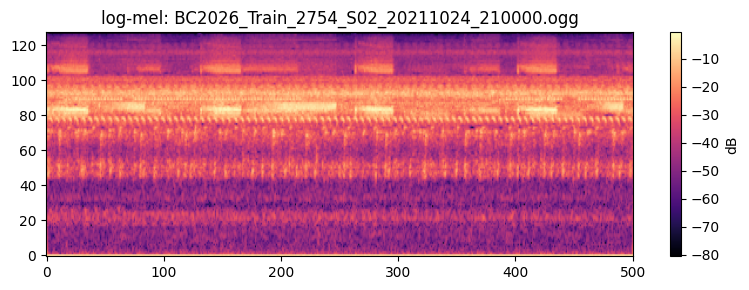

In [21]:
import matplotlib.pyplot as plt
try:
    from src.audio import load_audio, logmel
    from src.config import SAMPLE_RATE, CLIP_SAMPLES
    SS_DIR = DATA / 'train_soundscapes'
    sample_file = next(SS_DIR.glob('*.ogg'))
    y = load_audio(sample_file)
    mel = logmel(y[:CLIP_SAMPLES])
    print('shape:', y.shape, '  duration:', len(y)/SAMPLE_RATE, 's')
    plt.figure(figsize=(8, 3))
    plt.imshow(mel, aspect='auto', origin='lower', cmap='magma')
    plt.title(f'log-mel: {sample_file.name}')
    plt.colorbar(label='dB')
    plt.tight_layout(); plt.show()
except Exception as e:
    print('skipped mel viz:', e)
